# ReACT 기반 Single Agent 구현

## 학습 목표

ReACT(Reasoning + Acting) 패턴의 에이전트를 LangGraph로 직접 구현하고, create_agent()와 비교하여 두 방식의 관계를 이해한다.

### ReACT 패턴이란
- Reasoning: LLM이 현재 상황을 분석하고 다음 행동을 계획한다
- Acting: 계획된 행동(도구 호출)을 실행한다
- Loop: 목표 달성까지 이 과정을 반복한다

### 워크 플로우

```
START → call_model → [tool_calls 있음?] ─┬─ Yes → tools → call_model (루프)
                                         └─ No  → END
```

### 필수 패키지
```bash
pip install langchain langgraph langchain-openai python-dotenv
```

In [11]:
import os
from typing import Literal
from dotenv import load_dotenv

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage
from langchain_core.tools import tool
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode

load_dotenv()
assert os.getenv("OPENAI_API_KEY"), "OPENAI_API_KEY가 설정되지 않았다."

llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)

## 1단계: 도구(Tool) 정의

@tool 데코레이터로 함수를 도구로 만든다. **docsting**이 곧 도구 설명서다.

LLM은 이 설명을 읽고 언제 어떤 도구를 쓸지 판단하므로, 명확하게 작성해야 한다.

In [12]:
@tool
def search(query: str) -> str:
    """주어진 쿼리로 정보를 검색한다. 최신 정보나 사실 확인이 필요할 때 사용한다.

    Args:
        query: 검색할 질문이나 키워드
    """
    # 실습용 시뮬레이션 (실전에서는 Tavily 등 검색 API 호출)
    mock_results = {
        "langgraph": "LangGraph는 LangChain에서 만든 에이전트 워크플로우 프레임워크입니다. StateGraph로 복잡한 에이전트 로직을 구현할 수 있습니다.",
        "react": "ReACT는 Reasoning과 Acting을 결합한 에이전트 패턴으로, LLM이 추론과 행동을 번갈아 수행합니다."
    }
    for key, value in mock_results.items():
        if key in query.lower():
            return value
    return f"'{query}'에 대한 검색 결과를 찾지 못했습니다."

@tool
def calculator(expression: str) -> str:
    """수학 표현식을 계산한다.
    
    Args:
        expression: 계산할 수학 표현식 (예: '2 + 3 * 5')
    """
    # 주의: eval()은 임의 코드를 실행할 수 있어 위험하다.
    # 숫자와 사칙연산 기호만 허용하여 최소한의 안전장치를 둔다.
    import re
    if not re.fullmatch(r"[\d\s+\-*/().%]+", expression) or "**" in expression or len(expression) > 50:
        return "계산 오류: 숫자와 사칙연산 기호만 입력 가능합니다."
    try:
        return f"{expression} = {eval(expression)}"
    except Exception as e:
        return f"계산 오류: {e}"


tools = [search, calculator]
llm_with_tools = llm.bind_tools(tools)

## 2단계: State와 노드 정의

MessagesState는 LangGraph가 제공하는 기본 State로, messages 필드에 대화 메세지가 자동 누적된다 (add_messages 리듀서 내장). 별도 State 정의 없이 바로 사용한다.

노드는 2개면 충분하다:

| 노드 | 역할 |
|------|------|
| `call_model` | LLM 호출 — 답변하거나 도구 호출을 결정 (Reasoning) |
| `tools` | `ToolNode`(prebuilt) — LLM이 요청한 도구를 실행 (Acting) |

In [13]:
SYSTEM_PROMPT = (
    "You are a helpful AI assistant with access to tools. "
    "Use the available tools to answer user questions accurately. "
    "Always respond in Korean."
)

def call_model(state: MessagesState) -> dict:
    # Reasoning: LLM이 대화 이력을 보고 답변 또는 도구 호출을 결정
    print("[Reasoning] 모델 호출")
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

def should_continue(state: MessagesState) -> Literal["tools", END]:
    # 마지막 AI 메세지에 tool_calls가 있으면 Acting, 없으면 종료
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        print(f"[Acting] 도구 호츌: {[tc['name'] for tc in last_message.tool_calls]}")
        return "tools"
    return END

tool_node = ToolNode(tools) # 도구 실행 담당 prebuilt 노드

## 3단계: 그래프 구성과 히각화

tools -> call_model 엣지가 ReACT 루프의 핵심이다. 도구 실행 결과가 다시 모델에게 전달되어, 모델이 추가 도구 호출 또는 최종 답변을 결정한다.

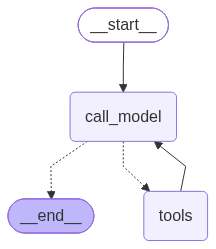

In [14]:
workflow = StateGraph(MessagesState)

workflow.add_node("call_model", call_model)
workflow.add_node("tools", tool_node)

workflow.add_edge(START, "call_model")
workflow.add_conditional_edges("call_model", should_continue)  # 분기
workflow.add_edge("tools", "call_model") # ReACT 루프

react_agent = workflow.compile()

from IPython.display import Image, display
try:
    display(Image(react_agent.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"PNG 렌더링 실패({e}) -> Mermaid 텍스트로 출력한다.\n")
    print(react_agent.get_graph().draw_mermaid())

## 4단계: 실행 및 테스트

도구가 필요 없는 질문, 검색 도구, 계산 도구를 각각 테스트한다.

In [15]:
def ask(agent, question: str):
    print("=" * 60)
    print(f"질문: {question}")
    result = agent.invoke({"messages": [{"role": "user", "content": question}]})
    print(f"답변: {result['messages'][-1].content}\n")
    return result

result = ask(react_agent, "안녕하세요! 반값습니다.") # 도구 불필요 -> 바로 답변
result = ask(react_agent, "LangGraph가 뭔지 검색해서 알려줘") # search 도구
result = ask(react_agent, "(15 + 27) * 3을 계산해줘") # calcultor 도구

질문: 안녕하세요! 반값습니다.
[Reasoning] 모델 호출
답변: 안녕하세요! 반갑습니다. 어떻게 도와드릴까요?

질문: LangGraph가 뭔지 검색해서 알려줘
[Reasoning] 모델 호출
[Acting] 도구 호츌: ['search']
[Reasoning] 모델 호출
답변: LangGraph는 LangChain에서 개발한 에이전트 워크플로우 프레임워크입니다. 이 프레임워크는 StateGraph를 사용하여 복잡한 에이전트 로직을 구현할 수 있도록 돕습니다.

질문: (15 + 27) * 3을 계산해줘
[Reasoning] 모델 호출
[Acting] 도구 호츌: ['calculator']
[Reasoning] 모델 호출
답변: (15 + 27) * 3의 계산 결과는 126입니다.



## 스트리밍으로 실행 과정 관찰

Stream()을 사용하면 노드 단위로 중간 결과를 확인할 수 있다.

Reasoning -> Acting -> Reasoning의 반복이 그대로 드러난다.

In [16]:
for chunk in react_agent.stream(
    {"messages": [{"role": "user", "content": "ReACT 패턴을 검색하고, 3 * 7도 계산해줘"}]}
):
    for node_name, value in chunk.items():
        last_msg = value["messages"][-1]
        if node_name == "tools":
            print(f"    [TOOLS 결과] {last_msg.content[:80]}")
        elif last_msg.tool_calls:
            pass # 도구 호출 결정은 should_continue에서 이미 출력
        else:
            print(f"\n최종 답변: {last_msg.content}")

[Reasoning] 모델 호출
[Acting] 도구 호츌: ['search', 'calculator']
    [TOOLS 결과] 3 * 7 = 21
[Reasoning] 모델 호출

최종 답변: ReACT 패턴은 Reasoning과 Acting을 결합한 에이전트 패턴으로, LLM이 추론과 행동을 번갈아 수행하는 방식입니다.

계산 결과는 3 * 7 = 21입니다.


## 5단계: create_agent()와 비교

위에서 직접 만든 그래프를 LangCahin의 create_agent()는 **한 줄로** 만들어 준다.

In [17]:
from langchain.agents import create_agent

# 1~3단계(State, 노드, 엣지, 컴파일)가 이 한 줄에 해당한다
prebuilt_agent = create_agent(
    model = 'gpt-4o-mini',
    tools = tools, # 위에서 정의한 도구 재사용
    system_prompt = SYSTEM_PROMPT
)

result = ask(prebuilt_agent, "(15 + 27) * 3을 계산해줘")

질문: (15 + 27) * 3을 계산해줘
답변: (15 + 27) * 3의 계산 결과는 126입니다.



In [18]:
# 두 에이전트의 그래프 구조를 비교하면 사실상 동일하다
print("[수동 구현 그래프]")
print(react_agent.get_graph().draw_mermaid())
print("\n[create_agent 그래프]")
print(prebuilt_agent.get_graph().draw_mermaid())

[수동 구현 그래프]
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	call_model(call_model)
	tools(tools)
	__end__([<p>__end__</p>]):::last
	__start__ --> call_model;
	call_model -.-> __end__;
	call_model -.-> tools;
	tools --> call_model;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc


[create_agent 그래프]
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	model(model)
	tools(tools)
	__end__([<p>__end__</p>]):::last
	__start__ --> model;
	model -.-> __end__;
	model -.-> tools;
	tools -.-> model;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc

